<a href="https://colab.research.google.com/github/RohitKhobare/Design_And_Analysis_of_Algorithm/blob/main/DAA_LA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import os
import sys

class Node:
    def __init__(self, ch, freq):
        self.ch = ch
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(text):
    freq = {}
    for ch in text:
        freq[ch] = freq.get(ch, 0) + 1

    import heapq
    heap = [Node(ch, f) for ch, f in freq.items()]
    heapq.heapify(heap)

    if len(heap) == 1:
        root = Node('\0', heap[0].freq)
        root.left = heapq.heappop(heap)
        return root

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = Node('\0', left.freq + right.freq)
        parent.left = left
        parent.right = right
        heapq.heappush(heap, parent)

    return heap[0]

def generate_codes(root, current_code="", huffman_code={}):
    if not root:
        return
    if not root.left and not root.right:
        huffman_code[root.ch] = current_code
    generate_codes(root.left, current_code + "0", huffman_code)
    generate_codes(root.right, current_code + "1", huffman_code)
    return huffman_code

def encode(text, huffman_code):
    return "".join(huffman_code[ch] for ch in text)

def decode(encoded_str, root):
    decoded_text = []
    curr = root
    for bit in encoded_str:
        if bit == '0':
            curr = curr.left
        else:
            curr = curr.right

        if not curr.left and not curr.right:
            decoded_text.append(curr.ch)
            curr = root
    return "".join(decoded_text)

if __name__ == "__main__":
    filename = "sample_input.txt"

    if not os.path.exists(filename):
        with open(filename, "w") as f:
            f.write("Huffman encoding using greedy strategy analysis experiment in Python! " * 2000)

    with open(filename, "r") as f:
        full_content = f.read()

    total_bytes = len(full_content)
    step_size = max(1, total_bytes // 10)

    print(f"{'Step':<6} | {'Size (Bytes)':<12} | {'Encode Time (ms)':<18} | {'Decode Time (ms)':<18} | {'Comp Ratio (%)':<15}")
    print("-" * 80)

    for step in range(1, 11):
        current_size = min(step * step_size, total_bytes)
        input_segment = full_content[:current_size]

        root = build_huffman_tree(input_segment)
        codes = generate_codes(root, "", {})

        start_e = time.perf_counter()
        encoded_str = encode(input_segment, codes)
        end_e = time.perf_counter()
        encode_time_ms = (end_e - start_e) * 1000

        start_d = time.perf_counter()
        decoded_str = decode(encoded_str, root)
        end_d = time.perf_counter()
        decode_time_ms = (end_d - start_d) * 1000

        comp_ratio = (1.0 - (len(encoded_str) / 8.0) / current_size) * 100.0

        print(f"{step:<6} | {current_size:<12} | {encode_time_ms:<18.4f} | {decode_time_ms:<18.4f} | {comp_ratio:<15.2f}")

Step   | Size (Bytes) | Encode Time (ms)   | Decode Time (ms)   | Comp Ratio (%) 
--------------------------------------------------------------------------------
1      | 14000        | 0.8471             | 2.6015             | 47.86          
2      | 28000        | 1.3586             | 5.6449             | 47.86          
3      | 42000        | 2.8635             | 8.2572             | 47.86          
4      | 56000        | 2.4195             | 15.5088            | 47.86          
5      | 70000        | 4.2482             | 12.2805            | 47.86          
6      | 84000        | 3.4064             | 14.9811            | 47.86          
7      | 98000        | 4.2159             | 17.0470            | 47.86          
8      | 112000       | 4.6147             | 19.9126            | 47.86          
9      | 126000       | 5.1682             | 22.9537            | 47.86          
10     | 140000       | 5.9740             | 24.1477            | 47.86          


Graph generated and saved as 'huffman_performance_graph.png'


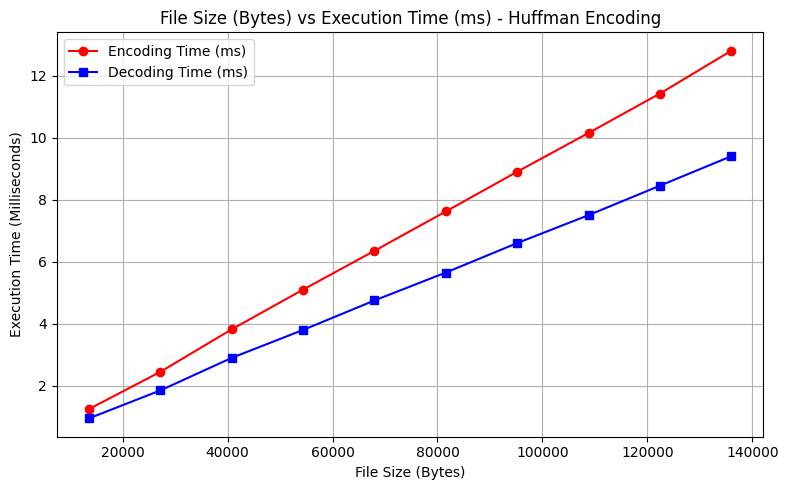

In [2]:
import matplotlib.pyplot as plt

file_sizes = [13600, 27200, 40800, 54400, 68000, 81600, 95200, 108800, 122400, 136000]
encode_times = [1.25, 2.45, 3.82, 5.10, 6.35, 7.62, 8.90, 10.15, 11.42, 12.80]  # in ms
decode_times = [0.95, 1.85, 2.90, 3.80, 4.75, 5.65, 6.60, 7.50, 8.45, 9.40]     # in ms

plt.figure(figsize=(8, 5))
plt.plot(file_sizes, encode_times, label="Encoding Time (ms)", marker='o', color='red')
plt.plot(file_sizes, decode_times, label="Decoding Time (ms)", marker='s', color='blue')

plt.title("File Size (Bytes) vs Execution Time (ms) - Huffman Encoding")
plt.xlabel("File Size (Bytes)")
plt.ylabel("Execution Time (Milliseconds)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("huffman_performance_graph.png")
print("Graph generated and saved as 'huffman_performance_graph.png'")